M1-M4 are the assumed models. M1-M12 are observation data-generating processes.

DeepSet, `S=2D`, 10 observations. Use the previously trained 40d/10n networks.
Sparse OOD data: for M5-M12, only the first `1` dimensions follow the source-model setting; the remaining dimensions follow M1.
This notebook uses l2 summary distance by default and writes to a sparse-specific result directory.


In [14]:
import pickle
from pathlib import Path

import bayesflow as bf
import keras
import numpy as np
import pandas as pd

from benchmark.examples.gaussian.datasets.datasets import GetDatasets
from benchmark.examples.gaussian.datasets.calculation import Calculation
from benchmark.examples.gaussian.analysis import summry_diagnostic as sd
sd.quiet_bayesflow_progress()

In [15]:
RNG = np.random.default_rng(2025)
num_dims = 20
num_obs = 10
num_datasets = 50
num_samples = 1000
n_ref = 2000

# Change this to 5 for the five-dimensional sparse misspecification experiment.
sparse_dims = 1
sparse_indices = np.arange(sparse_dims)
sparse_sources = tuple(f"m{i}" for i in range(5, 13))
distance_metric = "l2"

project_dir = Path("/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian")
network_dir = project_dir / "networks"
result_tag = f"40d_10n_sparse{sparse_dims}_{distance_metric}"
result_dir = project_dir / "results" / f"ood_{result_tag}"
dataset_dir = result_dir / "datasets"
figure_dir = result_dir / "figures"

source_specs = {
    "m1": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m2": {"mu_prior_mean": 3.0, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m3": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 3.0},
    "m4": {"mu_prior_mean": 0.1, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m5": {"mu_prior_mean": 1.5, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m6": {"mu_prior_mean": 5.0, "mu_prior_std": 1.0, "likelihood_std": 1.0},
    "m7": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 5.0},
    "m8": {"mu_prior_mean": 0.0, "mu_prior_std": 3.0, "likelihood_std": 1.0},
    "m9": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 0.1},
    "m10": {"mu_prior_mean": 0.0, "mu_prior_std": 1.0, "likelihood_std": 0.01},
    "m11": {"mu_prior_mean": 0.0, "mu_prior_std": 0.1, "likelihood_std": 1.0},
    "m12": {"mu_prior_mean": 0.0, "mu_prior_std": 0.01, "likelihood_std": 1.0},
}
assumed_specs = {key: source_specs[key] for key in sd.ASSUMED_MODELS}
base_spec = source_specs["m1"]

print("result_dir:", result_dir)
print("sparse_dims:", sparse_dims)
print("sparse_sources:", sparse_sources)

result_dir: /Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/gaussian/results/ood_40d_10n_sparse1_l2
sparse_dims: 1
sparse_sources: ('m5', 'm6', 'm7', 'm8', 'm9', 'm10', 'm11', 'm12')


In [16]:
def save_pickle(obj, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("wb") as file:
        pickle.dump(obj, file)


def load_pickle(path):
    with Path(path).open("rb") as file:
        return pickle.load(file)

In [17]:
# get datasets
logmlpmp_dataset_dir=project_dir / "results" / "ood_40d_10n_sparse1_linf"/"datasets"
datasets = {source: load_pickle(logmlpmp_dataset_dir / f"{source}_logml_pmp.pkl") for source in sd.SOURCE_MODELS}

In [18]:
# Load trained approximators
filepath_m1 = network_dir / "m1_s_40d_10n.keras"
filepath_m2 = network_dir / "m2_s_40d_10n.keras"
filepath_m3 = network_dir / "m3_s_40d_10n.keras"
filepath_m4 = network_dir / "m4_s_40d_10n.keras"
filepath_direct = network_dir / "direct_s_20d_10n.keras"

approximator_m1 = keras.saving.load_model(filepath_m1)
approximator_m2 = keras.saving.load_model(filepath_m2)
approximator_m3 = keras.saving.load_model(filepath_m3)
approximator_m4 = keras.saving.load_model(filepath_m4)

approximator_direct = keras.saving.load_model(filepath_direct)

approximators = {"m1": approximator_m1, "m2": approximator_m2, "m3": approximator_m3, "m4": approximator_m4}

In [19]:
# Fit summary-space reference distributions under the assumed models.
# These simulators stay unchanged because the neural networks and assumed models are unchanged.
def make_simulator(spec, seed):
    rng = np.random.default_rng(seed)

    def prior():
        mu = rng.normal(loc=spec["mu_prior_mean"], scale=spec["mu_prior_std"], size=num_dims)
        return {"mu": mu}

    def likelihood(mu):
        x = rng.normal(loc=mu, scale=spec["likelihood_std"], size=(num_obs, num_dims))
        return {"x": x}

    return bf.make_simulator([prior, likelihood])


simulators = {
    assumed: make_simulator(assumed_specs[assumed], 3025 + i)
    for i, assumed in enumerate(sd.ASSUMED_MODELS)
}
references = sd.fit_summary_references(
    approximators,
    simulators,
    n_ref=n_ref,
    distance_metric=distance_metric,
    alpha=0.1,
)

pd.DataFrame({
    k: {
        "metric": v["distance_metric"],
        "summary_dim": v["summary_dim"],
        "dm_low": v["dm_low"],
        "dm_high": v["dm_high"],
        "median": v["median"],
        
    }
    for k, v in references.items()
}).T

,metric,summary_dim,dm_low,dm_high,median
m1,l2,40,0.624468,0.909695,0.735834
m2,l2,40,0.63305,0.908879,0.741924
m3,l2,40,0.58424,0.957554,0.745568
m4,l2,40,0.632917,0.908528,0.735831


In [20]:
# Add dynamic distance regimes and x(y) score.
datasets = sd.add_distances_and_regimes(datasets, approximators, references)

posterior_df = sd.collect_posterior_distance_frame(datasets, n_samples=1000)
logml_df = sd.collect_logml_distance_frame(datasets)
pmp_df = sd.collect_pmp_ambiguity_frame(datasets)
logml_summary, pmp_summary = sd.summarize_frames(logml_df, pmp_df)

result_dir.mkdir(parents=True, exist_ok=True)
posterior_df.to_csv(result_dir / f"posterior_distance_frame_{result_tag}.csv", index=False)
logml_df.to_csv(result_dir / f"logml_distance_frame_{result_tag}.csv", index=False)
pmp_df.to_csv(result_dir / f"pmp_ambiguity_frame_{result_tag}.csv", index=False)
logml_summary.to_csv(result_dir / f"logml_summary_{result_tag}.csv", index=False)
pmp_summary.to_csv(result_dir / f"pmp_summary_{result_tag}.csv", index=False)
for source, data in datasets.items():
    save_pickle(data, dataset_dir / f"{source}_processed_{result_tag}.pkl")

In [21]:
# # Load sparse datasets for plotting.
# datasets = {
#     source: load_pickle(dataset_dir / f"{source}_processed_{result_tag}.pkl")
#     for source in sd.SOURCE_MODELS
# }
# posterior_df = pd.read_csv(result_dir / f"posterior_distance_frame_{result_tag}.csv")
# logml_df = pd.read_csv(result_dir / f"logml_distance_frame_{result_tag}.csv")
# pmp_df = pd.read_csv(result_dir / f"pmp_ambiguity_frame_{result_tag}.csv")

## Plots

In [ ]:
# signed logml error with shared y-axis
sd.plot_logml_error_vs_distance(logml_df, color_by="source", output_dir=figure_dir);
# sd.plot_logml_error_vs_distance(logml_df, color_by="gold_logml", output_dir=figure_dir);

In [ ]:
# PMP plots
sd.plot_pmp_diagnostic(pmp_df,x="rho",y="signed_error",group_by="global_extrapolation_source",estimate="npe",output_dir=None,regions="assumed",sharex=True,x_min=0.0,error_bound=0.05,distance_metric="l2",)

In [26]:
# # PMP estimates (NPE and NPMP) vs distance for each source model
# for source in sd.SOURCE_MODELS:
#     sd.plot_pmp_estimates_vs_distance(pmp_df, source,output_dir=figure_dir)

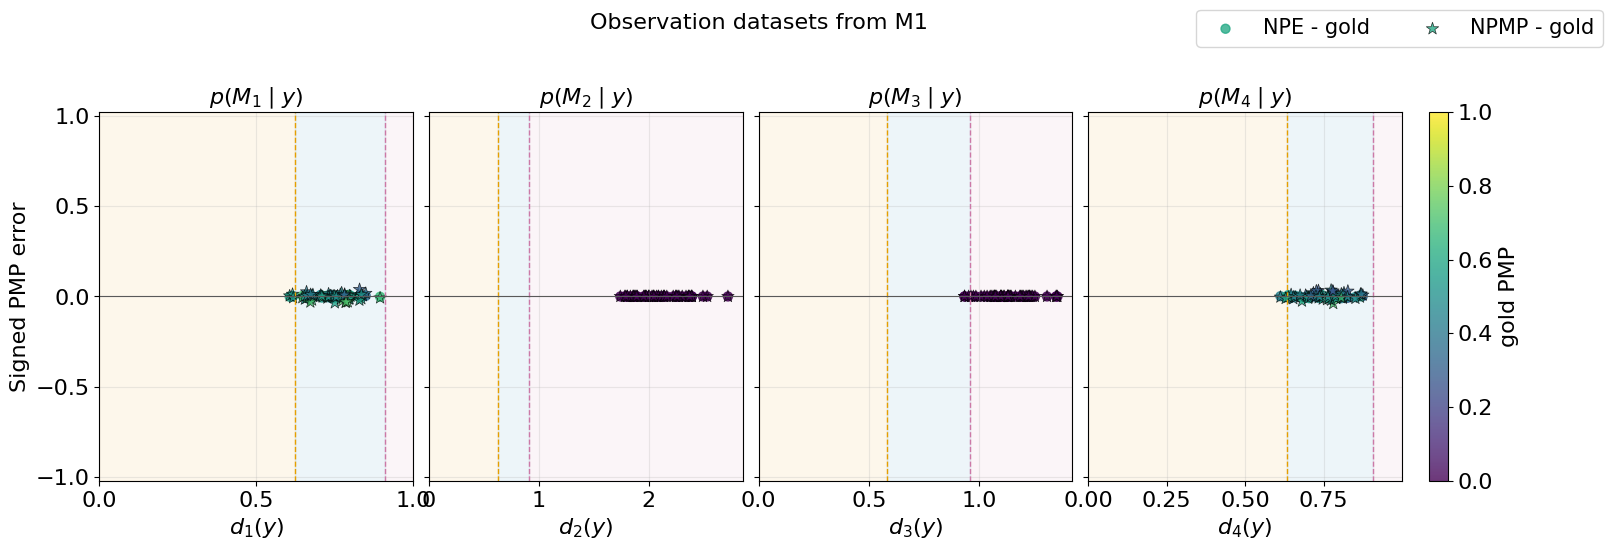

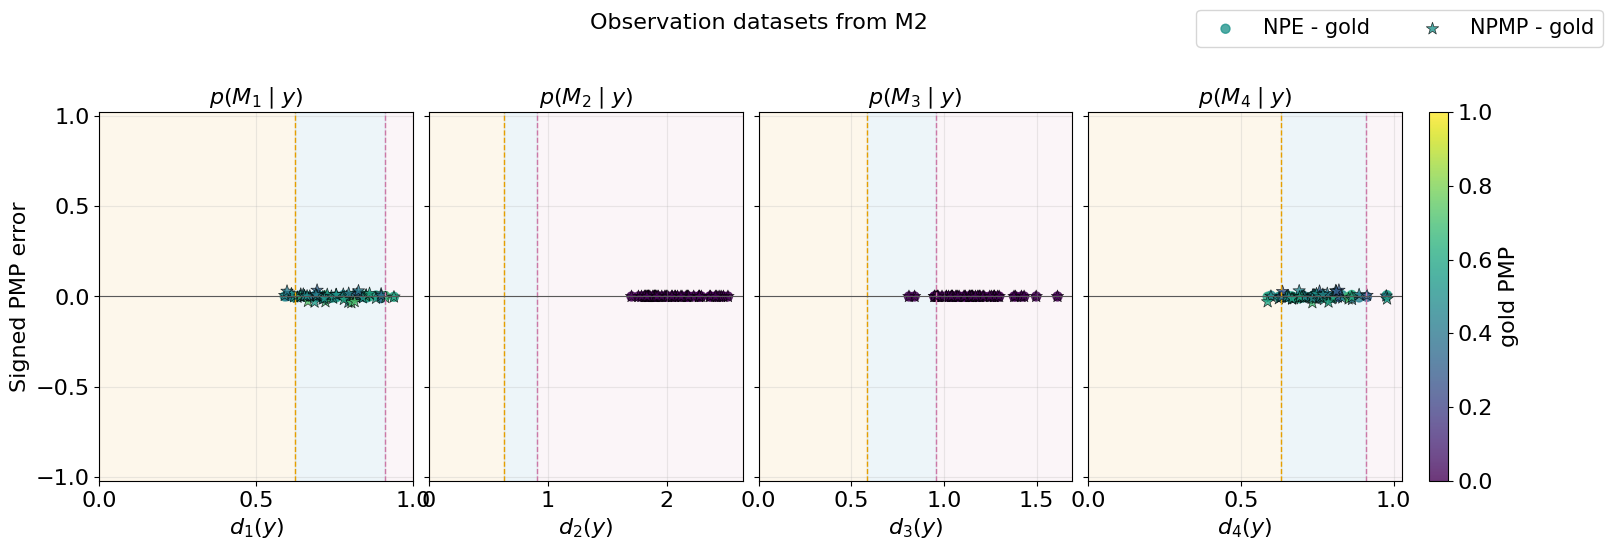

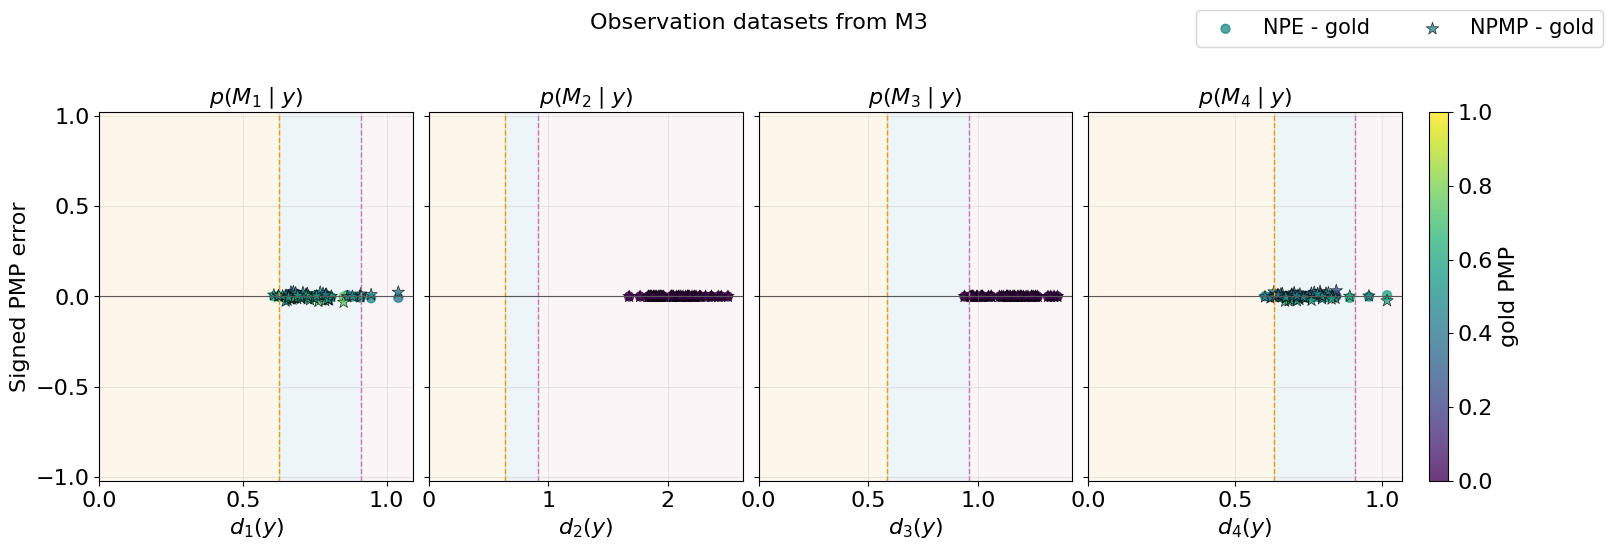

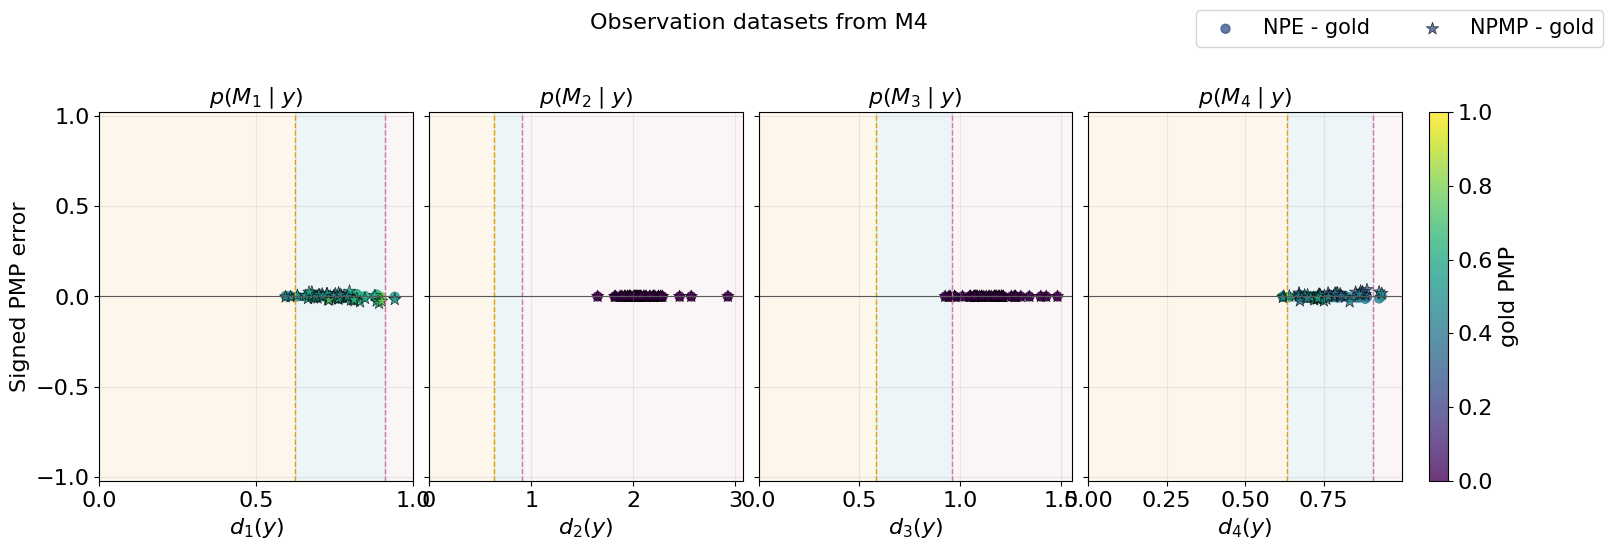

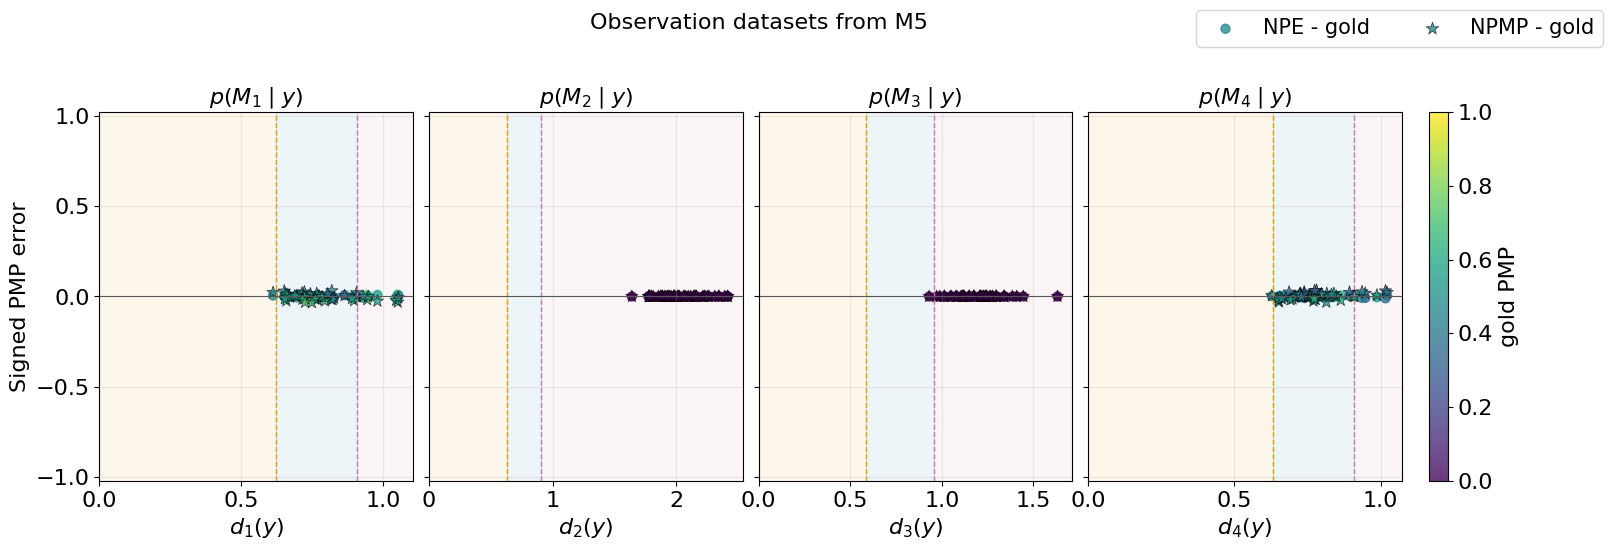

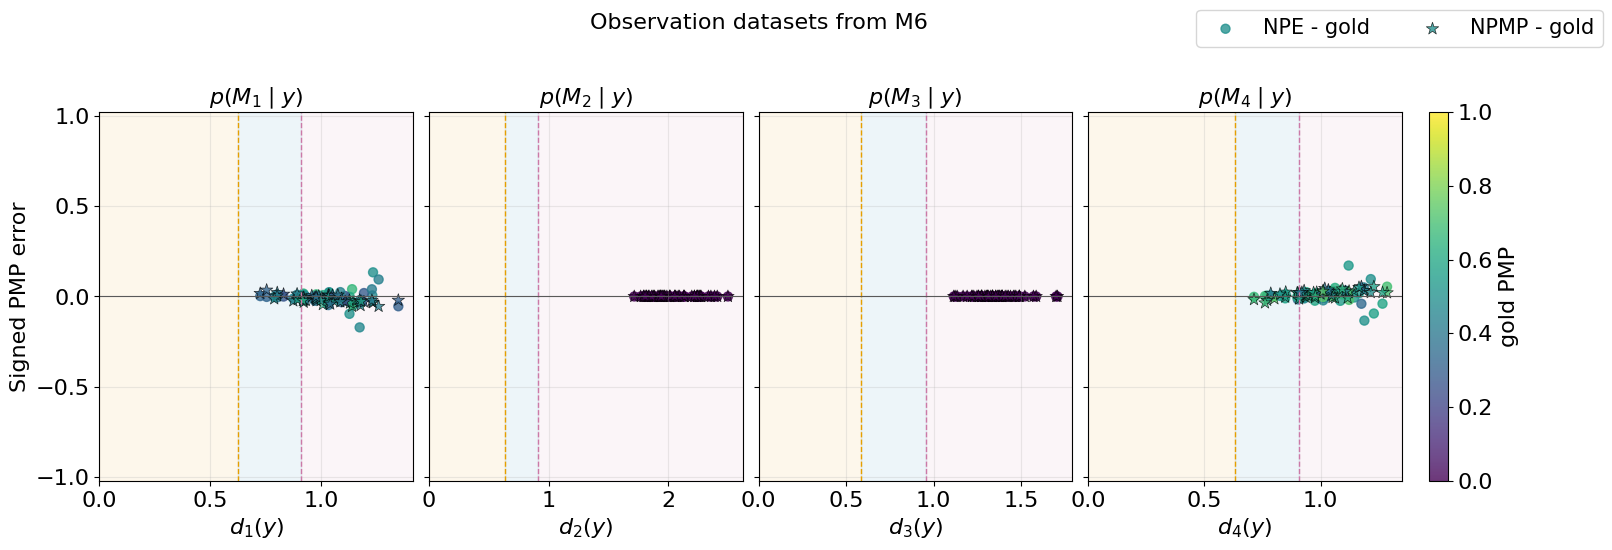

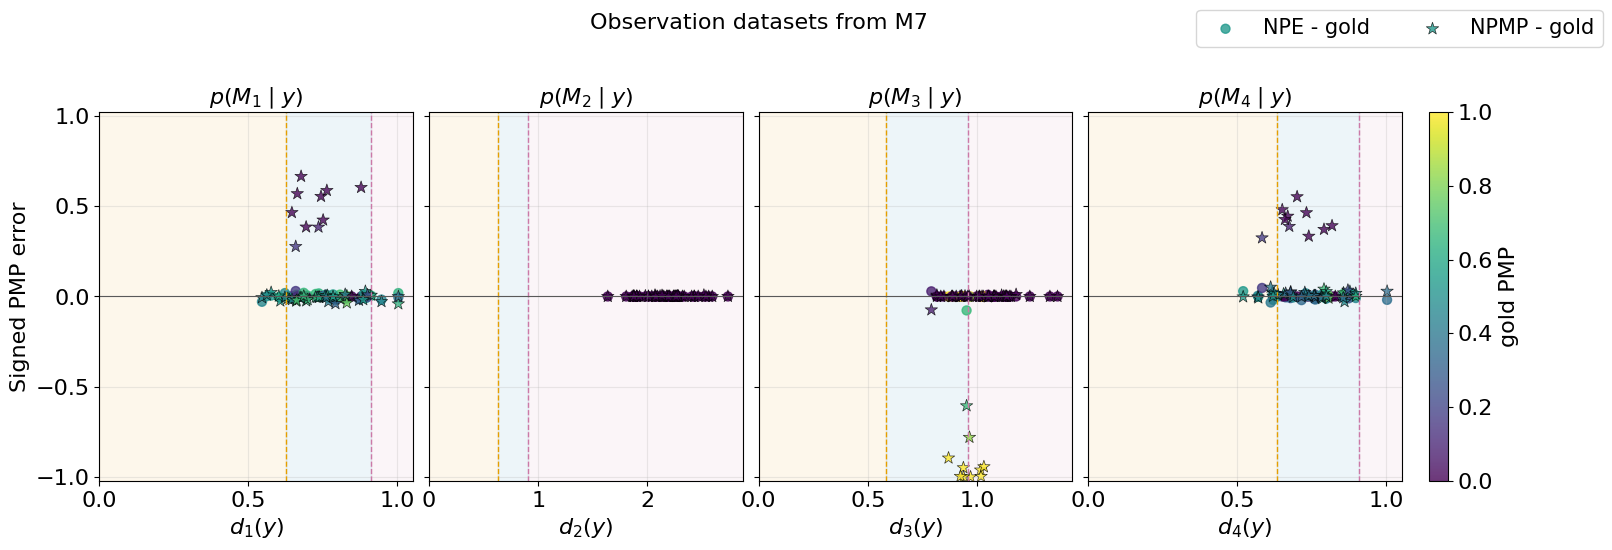

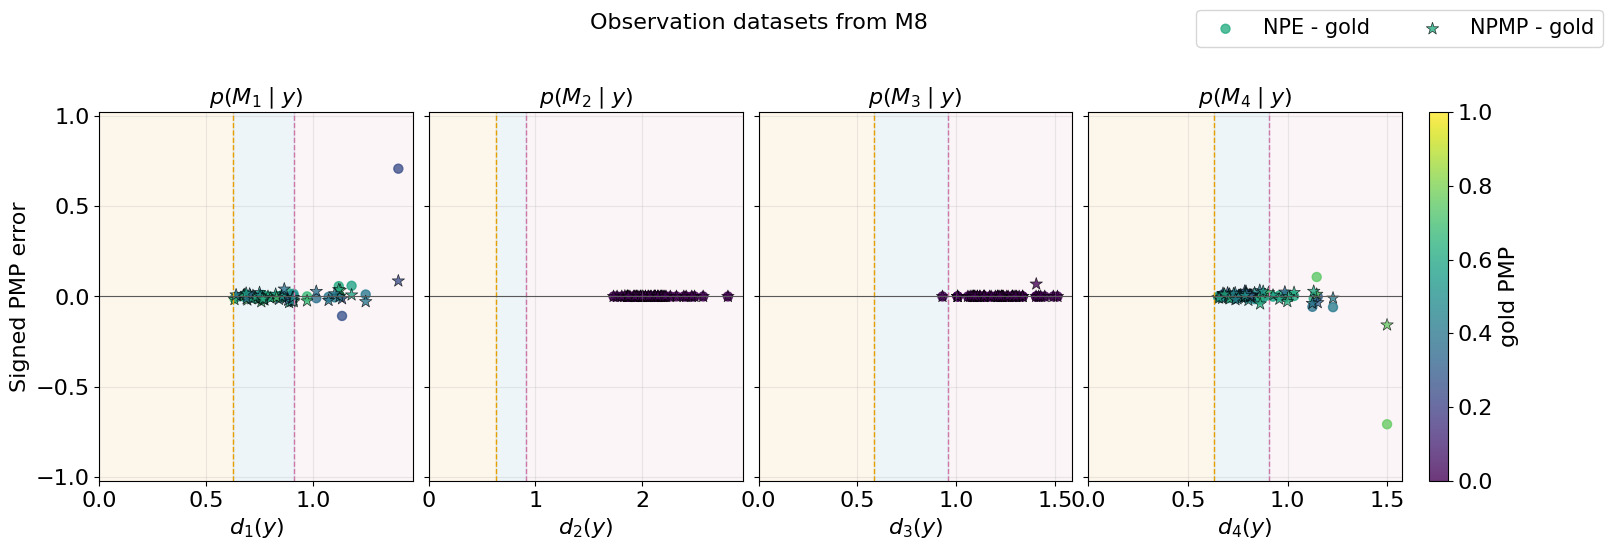

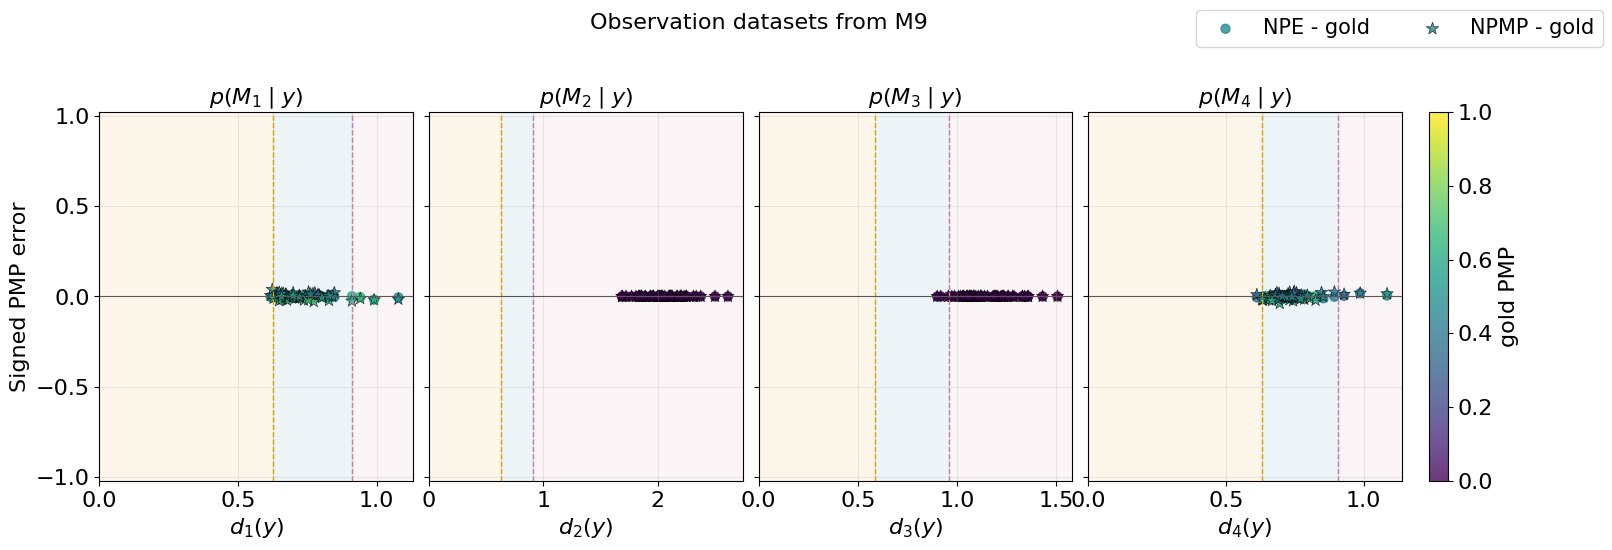

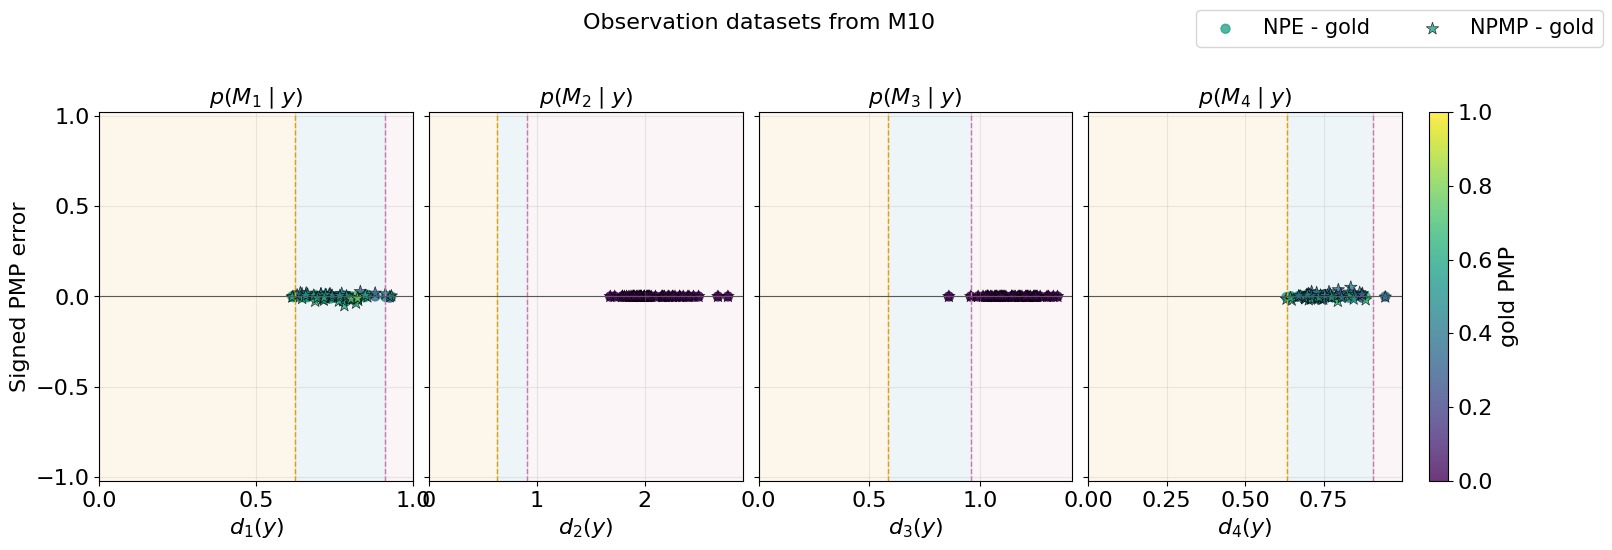

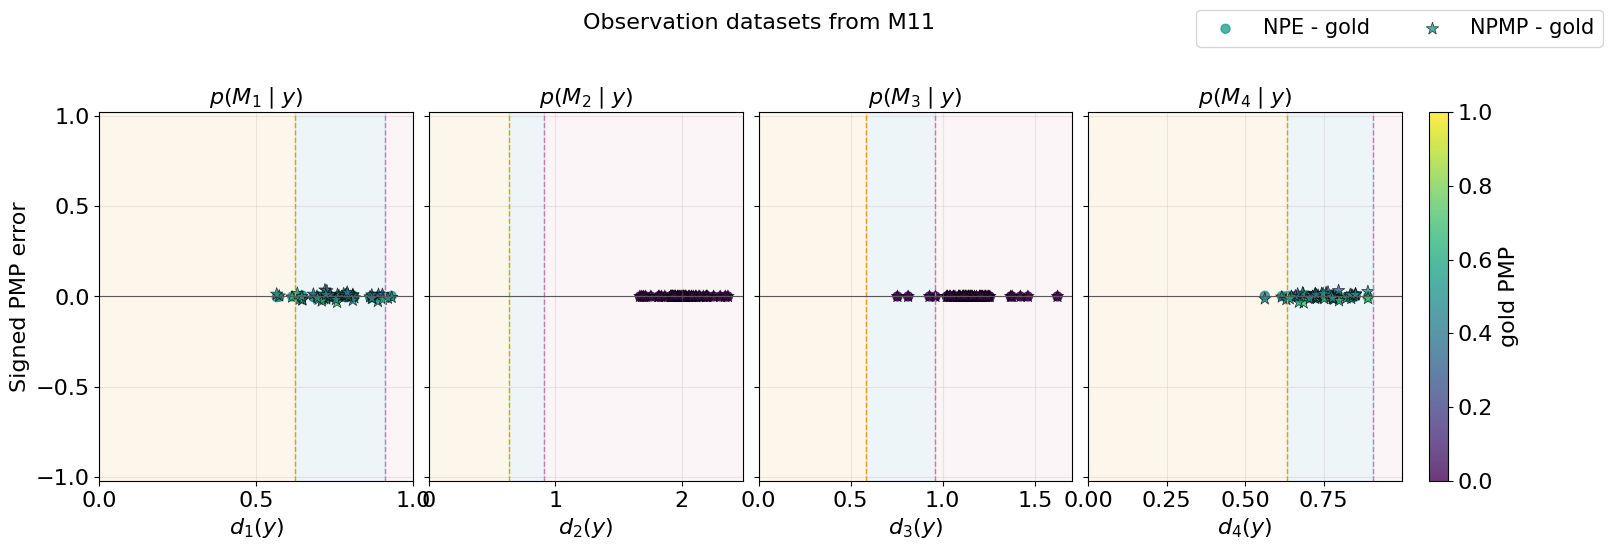

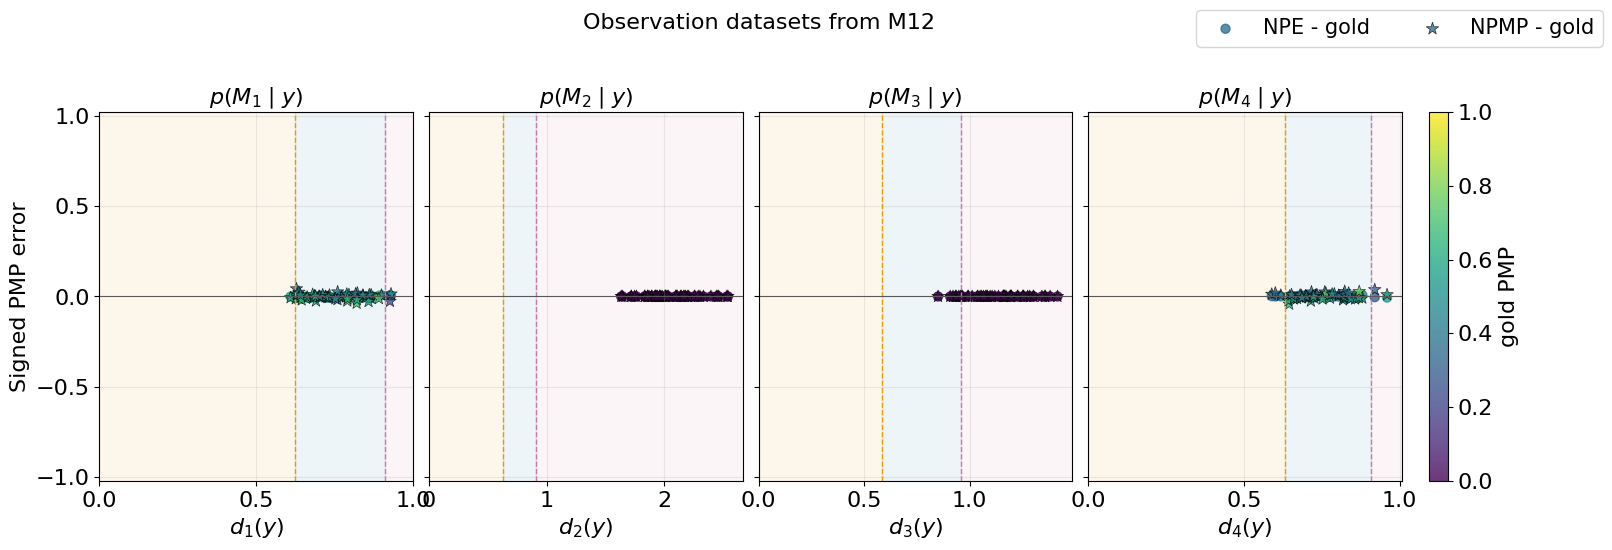

In [27]:
# PMP estimates (NPE and NPMP) vs distance for each source model
for source in sd.SOURCE_MODELS:
    sd.plot_pmp_estimates_vs_distance(pmp_df, source,x="distance",y="signed_error",output_dir=figure_dir)